# Rueda cromatica HSV

Este cuaderno te permite explorar el canal `H` de HSV como una rueda y como una barra lineal. La idea es entender mejor como se organizan los colores, por que el rojo aparece en dos extremos del rango y como elegir umbrales para segmentar colores como rojo, verde y azul.


## Referencia rapida

- En OpenCV, `H` va de `0` a `179`.
- `S` indica cuan puro es el color.
- `V` indica el brillo.
- El rojo es especial porque queda cerca de `H = 0` y tambien cerca de `H = 179`.
- Rangos aproximados utiles:
  - rojo: `0-10` y `170-179`
  - verde: `35-85`
  - azul: `90-130`


In [1]:
# Importamos NumPy para construir arreglos y hacer calculos numericos.
import numpy as np

# Importamos OpenCV para convertir imagenes entre HSV y RGB.
import cv2

# Importamos Matplotlib para visualizar la rueda y la barra cromatica.
import matplotlib.pyplot as plt

# Importamos widgets para agregar controles interactivos en el cuaderno.
from ipywidgets import interact, IntSlider


In [2]:
# Construimos una mascara de matiz que contempla el caso circular del rojo.
def mascara_hue(hue, h_min, h_max):
    if h_min <= h_max:
        return (hue >= h_min) & (hue <= h_max)
    return (hue >= h_min) | (hue <= h_max)


# Creamos una rueda cromatica HSV y resaltamos un rango de matiz.
def crear_rueda_hsv(tamano=500, h_min=0, h_max=10, saturacion_min=20, valor=255):
    centro = tamano // 2
    radio_max = tamano // 2 - 12

    y, x = np.indices((tamano, tamano))
    x_c = x - centro
    y_c = y - centro

    radio = np.sqrt(x_c ** 2 + y_c ** 2)
    angulo = np.arctan2(-y_c, x_c)

    hue = ((angulo + np.pi) / (2 * np.pi) * 179).astype(np.uint8)
    saturacion = np.clip((radio / radio_max) * 255, 0, 255).astype(np.uint8)
    value = np.full((tamano, tamano), valor, dtype=np.uint8)

    rueda_hsv = np.dstack((hue, saturacion, value))
    mascara_circulo = radio <= radio_max
    mascara_rango = mascara_hue(hue, h_min, h_max)
    mascara_visible = mascara_circulo & (saturacion >= saturacion_min)

    vista_hsv = rueda_hsv.copy()
    vista_hsv[mascara_visible & ~mascara_rango, 1] = 35
    vista_hsv[mascara_visible & ~mascara_rango, 2] = np.clip(valor * 0.45, 0, 255).astype(np.uint8)
    vista_hsv[~mascara_circulo] = 0

    rueda_rgb = cv2.cvtColor(rueda_hsv, cv2.COLOR_HSV2RGB)
    vista_rgb = cv2.cvtColor(vista_hsv, cv2.COLOR_HSV2RGB)
    return rueda_rgb, vista_rgb


# Creamos una barra lineal del canal H para ver el orden de los colores.
def crear_barra_hue(altura=60, ancho=720, h_min=0, h_max=10, saturacion=255, valor=255):
    hue_lineal = np.linspace(0, 179, ancho, dtype=np.uint8)
    barra_h = np.tile(hue_lineal, (altura, 1))
    barra_s = np.full((altura, ancho), saturacion, dtype=np.uint8)
    barra_v = np.full((altura, ancho), valor, dtype=np.uint8)

    barra_hsv = np.dstack((barra_h, barra_s, barra_v))
    barra_rgb = cv2.cvtColor(barra_hsv, cv2.COLOR_HSV2RGB)

    mascara_rango = mascara_hue(barra_h, h_min, h_max)
    barra_resaltada = barra_rgb.copy()
    barra_resaltada[~mascara_rango] = (barra_resaltada[~mascara_rango] * 0.28).astype(np.uint8)
    return barra_rgb, barra_resaltada


# Convertimos algunos valores de H en nombres orientativos para facilitar la lectura.
def describir_rango(h_min, h_max):
    if h_min <= h_max:
        amplitud = h_max - h_min
        texto_rango = f'Rango seleccionado: H = {h_min} a {h_max} (ancho {amplitud})'
    else:
        amplitud = (179 - h_min) + h_max + 1
        texto_rango = f'Rango seleccionado: H = {h_min} a 179 y 0 a {h_max} (ancho {amplitud})'

    if h_min > h_max:
        observacion = 'Este caso cruza el borde de la rueda. Asi se suele detectar el rojo.'
    elif h_max <= 15 or h_min >= 165:
        observacion = 'Estas cerca de la zona roja.'
    elif 35 <= h_min and h_max <= 85:
        observacion = 'Estas dentro de una zona tipica de verdes.'
    elif 90 <= h_min and h_max <= 130:
        observacion = 'Estas dentro de una zona tipica de azules.'
    else:
        observacion = 'Estas explorando un rango intermedio de la rueda cromatica.'

    return texto_rango, observacion


## Explorador interactivo

Moviendo `H min` y `H max` podes ver que parte de la rueda queda seleccionada. Si `H min` es mayor que `H max`, el rango se interpreta como circular y eso es especialmente util para el rojo.


In [3]:
# Mostramos la rueda, la barra de matices y una referencia de colores sugeridos.
def explorar_rueda_hsv(h_min=170, h_max=10, saturacion=255, valor=255):
    rueda_rgb, rueda_resaltada = crear_rueda_hsv(
        tamano=520,
        h_min=h_min,
        h_max=h_max,
        saturacion_min=20,
        valor=valor
    )

    barra_rgb, barra_resaltada = crear_barra_hue(
        altura=70,
        ancho=720,
        h_min=h_min,
        h_max=h_max,
        saturacion=saturacion,
        valor=valor
    )

    texto_rango, observacion = describir_rango(h_min, h_max)

    fig, ejes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

    ejes[0, 0].imshow(rueda_rgb)
    ejes[0, 0].set_title('Rueda HSV completa', fontweight='bold', loc='left')
    ejes[0, 0].axis('off')

    ejes[0, 1].imshow(rueda_resaltada)
    ejes[0, 1].set_title('Rango resaltado sobre la rueda', fontweight='bold', loc='left')
    ejes[0, 1].axis('off')

    ejes[1, 0].imshow(barra_rgb)
    ejes[1, 0].set_title('Barra lineal del canal H', fontweight='bold', loc='left')
    ejes[1, 0].set_xticks(np.linspace(0, 719, 7))
    ejes[1, 0].set_xticklabels(['0', '30', '60', '90', '120', '150', '179'])
    ejes[1, 0].set_yticks([])

    ejes[1, 1].imshow(barra_resaltada)
    ejes[1, 1].set_title('Rango resaltado sobre la barra', fontweight='bold', loc='left')
    ejes[1, 1].set_xticks(np.linspace(0, 719, 7))
    ejes[1, 1].set_xticklabels(['0', '30', '60', '90', '120', '150', '179'])
    ejes[1, 1].set_yticks([])

    plt.show()

    print(texto_rango)
    print(observacion)
    print('Referencias utiles: rojo 0-10 y 170-179 | verde 35-85 | azul 90-130')


interact(
    explorar_rueda_hsv,
    h_min=IntSlider(min=0, max=179, step=1, value=170, description='H min'),
    h_max=IntSlider(min=0, max=179, step=1, value=10, description='H max'),
    saturacion=IntSlider(min=60, max=255, step=5, value=255, description='S'),
    valor=IntSlider(min=60, max=255, step=5, value=255, description='V')
);


interactive(children=(IntSlider(value=170, description='H min', max=179), IntSlider(value=10, description='H m…

## Sugerencias para explorar

1. Proba primero con rojo usando `H min = 170` y `H max = 10`.
2. Despues proba verde con `35-85`.
3. Luego proba azul con `90-130`.
4. Cambia `S` y `V` para ver como se modifica la apariencia del color sin cambiar el orden del canal `H`.
5. Fijate que la barra es lineal, pero la rueda es circular. Esa es la clave para entender el rojo.


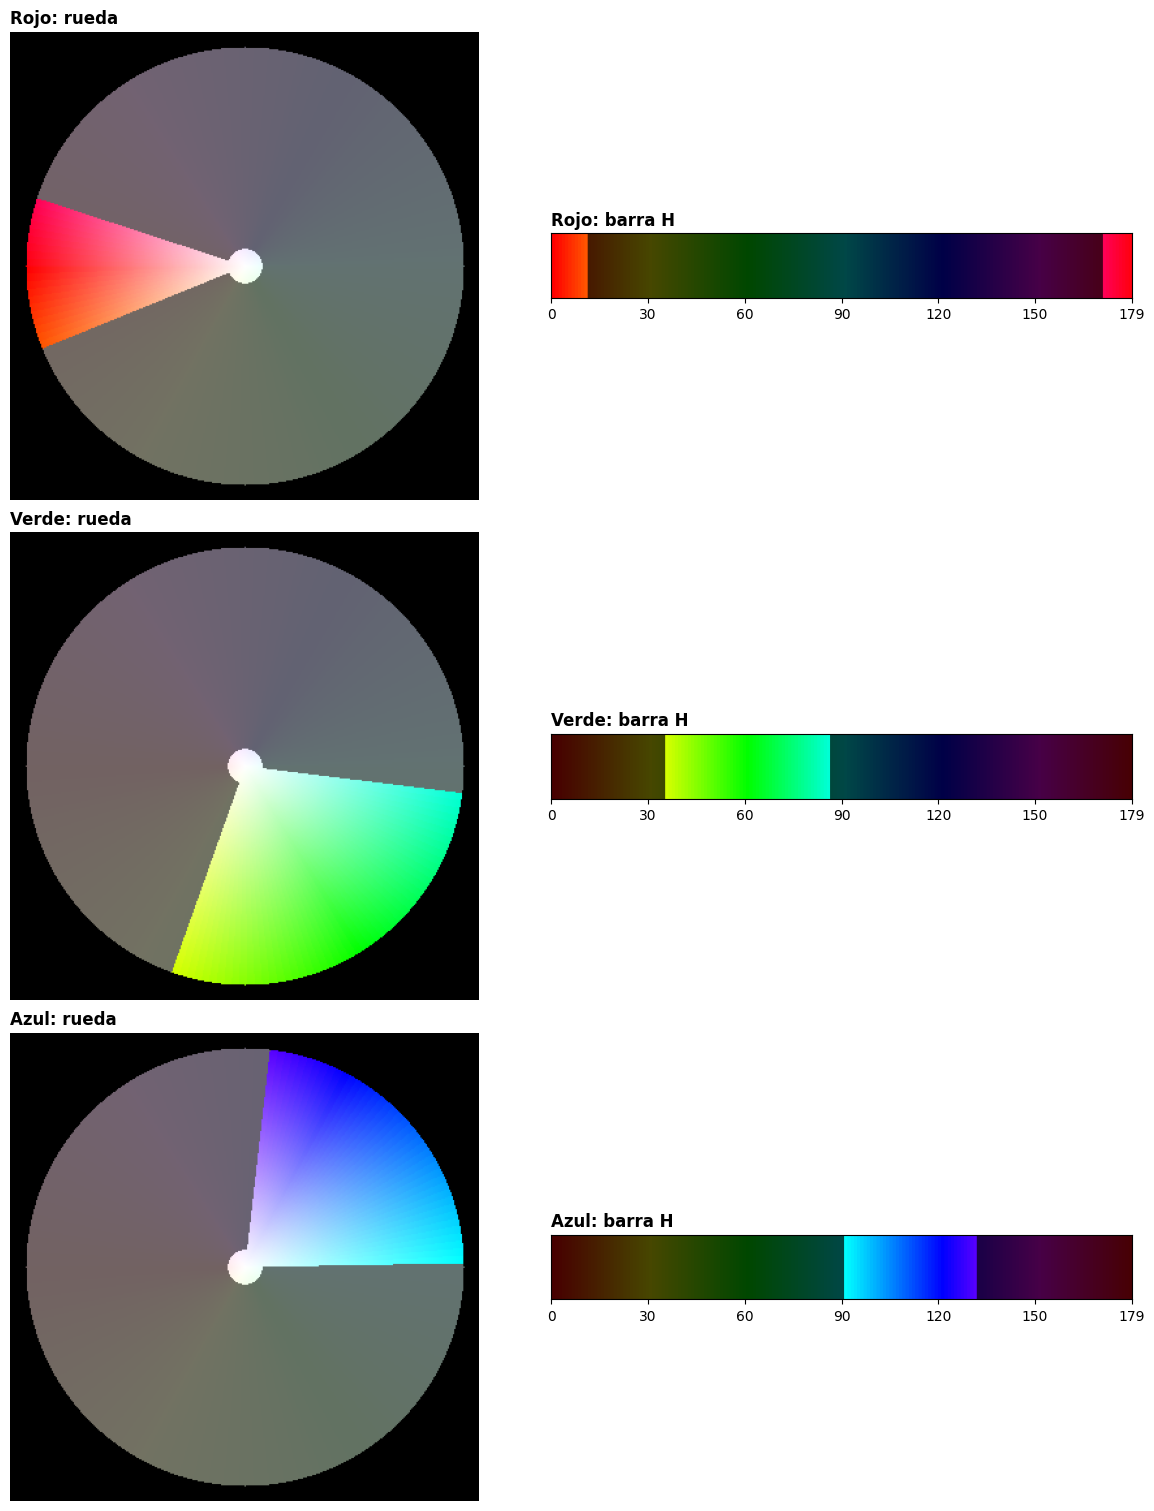

In [4]:
# Mostramos una comparacion fija para tres colores importantes en segmentacion.
rangos = {
    'Rojo': (170, 10),
    'Verde': (35, 85),
    'Azul': (90, 130),
}

fig, ejes = plt.subplots(3, 2, figsize=(12, 15), constrained_layout=True)

for fila, (nombre, (h_min, h_max)) in enumerate(rangos.items()):
    _, rueda_resaltada = crear_rueda_hsv(tamano=360, h_min=h_min, h_max=h_max, saturacion_min=20, valor=255)
    _, barra_resaltada = crear_barra_hue(altura=60, ancho=540, h_min=h_min, h_max=h_max, saturacion=255, valor=255)

    ejes[fila, 0].imshow(rueda_resaltada)
    ejes[fila, 0].set_title(f'{nombre}: rueda', fontweight='bold', loc='left')
    ejes[fila, 0].axis('off')

    ejes[fila, 1].imshow(barra_resaltada)
    ejes[fila, 1].set_title(f'{nombre}: barra H', fontweight='bold', loc='left')
    ejes[fila, 1].set_xticks(np.linspace(0, 539, 7))
    ejes[fila, 1].set_xticklabels(['0', '30', '60', '90', '120', '150', '179'])
    ejes[fila, 1].set_yticks([])

plt.show()


## Idea clave

En HSV, el matiz funciona como una circunferencia. Por eso el rojo aparece dividido en dos extremos cuando lo miras en una escala lineal de `0` a `179`. Entender esto ayuda mucho al momento de elegir rangos para segmentacion por color con OpenCV.
